# Encoding Atlas — Production Usage Guide

This notebook demonstrates **every way** the `encoding-atlas` library can be used in real-world quantum machine learning workflows. It covers:

| Section | Topic |
|---------|-------|
| **1** | Installation & Quick Start |
| **2** | The Encoding Catalog — All 16 Encodings |
| **3** | The Registry System — Dynamic Lookup & Custom Encodings |
| **4** | Capability Protocols — Runtime Feature Detection |
| **5** | Circuit Generation — Single, Batch & Multi-Backend |
| **6** | Encoding Properties & Resource Analysis |
| **7** | Simulability Analysis |
| **8** | Expressibility Analysis |
| **9** | Entanglement Capability Analysis |
| **10** | Trainability & Barren Plateau Detection |
| **11** | Low-Level Quantum Utilities |
| **12** | Visualization & Comparison Tools |
| **13** | Guided Encoding Selection |
| **14** | Benchmarking Datasets & Metrics |
| **15** | End-to-End Workflow: Quantum Kernel Classification |
| **16** | End-to-End Workflow: Encoding Selection Pipeline |
| **17** | Advanced: Trainable Encoding Optimization Loop |
| **18** | Advanced: Equivariance Verification |
| **19** | Production Patterns: Serialization, Error Handling, Logging |

---
## 1. Installation & Quick Start

In [39]:
# Install from TestPyPI (use PyPI for production releases)
!pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ encoding-atlas==0.1.0

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import encoding_atlas
print(f"encoding-atlas v{encoding_atlas.__version__}")

encoding-atlas v0.1.0


In [41]:
# Quick start: encode classical data into a quantum circuit in 3 lines
import numpy as np
from encoding_atlas import IQPEncoding

enc = IQPEncoding(n_features=4, reps=2, entanglement="full")
circuit = enc.get_circuit(np.array([0.1, 0.5, 0.3, 0.8]), backend="pennylane")
print(f"Created {enc.__class__.__name__} circuit — {enc.n_qubits} qubits, depth {enc.depth}")

Created IQPEncoding circuit — 4 qubits, depth 6


---
## 2. The Encoding Catalog — All 16 Encodings

The library ships **16 production-ready quantum encodings** organized in 6 families.
Each encoding maps classical feature vectors $\mathbf{x} \in \mathbb{R}^d$ to quantum states $|\psi(\mathbf{x})\rangle$.

### 2.1 Foundational Encodings

In [42]:
from encoding_atlas import AngleEncoding, AmplitudeEncoding, BasisEncoding

x4 = np.array([0.3, 1.2, 0.7, 2.1])

# --- Angle Encoding: R_y(x_i)|0> per qubit ---
angle = AngleEncoding(n_features=4, rotation="Y", reps=1)
print(f"AngleEncoding:     {angle.n_qubits} qubits, depth {angle.depth}, entangling={angle.properties.is_entangling}")

# Different rotation axes
angle_x = AngleEncoding(n_features=4, rotation="X")
angle_z = AngleEncoding(n_features=4, rotation="Z")

# Repeated layers for deeper circuits
angle_deep = AngleEncoding(n_features=4, rotation="Y", reps=3)
print(f"  reps=3 → depth {angle_deep.depth}")

AngleEncoding:     4 qubits, depth 1, entangling=False
  reps=3 → depth 3


In [43]:
# --- Amplitude Encoding: |ψ(x)> = Σ (x_i/||x||)|i> ---
# Encodes 2^n features into n qubits (exponential compression)
amp = AmplitudeEncoding(n_features=4, normalize=True)
print(f"AmplitudeEncoding: {amp.n_qubits} qubits for {amp.n_features} features (log2 compression)")
print(f"  entangling={amp.properties.is_entangling}, simulability={amp.properties.simulability}")

# Without auto-normalization (user must provide unit-norm input)
amp_raw = AmplitudeEncoding(n_features=4, normalize=False)

AmplitudeEncoding: 2 qubits for 4 features (log2 compression)
  entangling=True, simulability=not_simulable


In [44]:
# --- Basis Encoding: |ψ(x)> = |x_0 x_1 ... x_{n-1}> ---
# Maps binary data directly to computational basis states
basis = BasisEncoding(n_features=4, threshold=0.5)
binary_data = np.array([0.1, 0.9, 0.3, 0.8])  # → binarized to [0, 1, 0, 1]
print(f"BasisEncoding:     {basis.n_qubits} qubits, Clifford-only={basis.properties.simulability}")

# Custom threshold for binarization
basis_strict = BasisEncoding(n_features=4, threshold=0.3)

BasisEncoding:     4 qubits, Clifford-only=simulable


### 2.2 Feature Map Encodings

In [45]:
from encoding_atlas import IQPEncoding, ZZFeatureMap, PauliFeatureMap

# --- IQP Encoding: Hadamard + ZZ interactions (IQP-hard) ---
iqp_full = IQPEncoding(n_features=4, reps=2, entanglement="full")
iqp_linear = IQPEncoding(n_features=4, reps=2, entanglement="linear")
iqp_circular = IQPEncoding(n_features=4, reps=1, entanglement="circular")

print(f"IQP (full):     depth={iqp_full.depth}, pairs={len(iqp_full.get_entanglement_pairs())}")
print(f"IQP (linear):   depth={iqp_linear.depth}, pairs={len(iqp_linear.get_entanglement_pairs())}")
print(f"IQP (circular): depth={iqp_circular.depth}, pairs={len(iqp_circular.get_entanglement_pairs())}")

IQP (full):     depth=6, pairs=6
IQP (linear):   depth=6, pairs=3
IQP (circular): depth=3, pairs=4


In [46]:
# --- ZZ Feature Map: Qiskit-compatible ZZ entangling map ---
zz = ZZFeatureMap(n_features=4, reps=2, entanglement="full")
print(f"ZZFeatureMap:  depth={zz.depth}, entangling={zz.properties.is_entangling}")

# --- Pauli Feature Map: Fully configurable Pauli rotation layers ---
pauli = PauliFeatureMap(n_features=4, reps=2, paulis=["Z", "ZZ"], entanglement="full")
print(f"PauliFeatureMap: depth={pauli.depth}, paulis={pauli.paulis}")

ZZFeatureMap:  depth=22, entangling=True
PauliFeatureMap: depth=10, paulis=['Z', 'ZZ']


### 2.3 Advanced Multi-Layer Encodings

In [47]:
from encoding_atlas import DataReuploading, HardwareEfficientEncoding, HigherOrderAngleEncoding

# --- Data Reuploading: data re-encoded at every layer (universal approximation) ---
dr = DataReuploading(n_features=4, n_layers=3)
print(f"DataReuploading:          layers={dr.n_layers}, depth={dr.depth}, qubits={dr.n_qubits}")

# With fewer qubits than features (data gets wrapped across qubits)
dr_compact = DataReuploading(n_features=4, n_layers=2, n_qubits=2)
print(f"  compact (2 qubits):     depth={dr_compact.depth}")

DataReuploading:          layers=3, depth=12, qubits=4
  compact (2 qubits):     depth=6


In [48]:
# --- Hardware-Efficient Encoding: optimized for NISQ gate sets ---
hwe = HardwareEfficientEncoding(n_features=4, reps=2, rotation="Y", entanglement="linear")
print(f"HardwareEfficient: depth={hwe.depth}, entanglement={hwe.entanglement}")

# --- Higher-Order Angle Encoding: polynomial feature expansion ---
hoa = HigherOrderAngleEncoding(n_features=4, order=2, rotation="Y")
print(f"HigherOrderAngle:  order=2, qubits={hoa.n_qubits}, depth={hoa.depth}")

hoa3 = HigherOrderAngleEncoding(n_features=4, order=3, include_first_order=True)
print(f"  order=3:         qubits={hoa3.n_qubits}")

HardwareEfficient: depth=4, entanglement=linear
HigherOrderAngle:  order=2, qubits=4, depth=1
  order=3:         qubits=4


### 2.4 Specialized Encodings

In [49]:
from encoding_atlas import QAOAEncoding, HamiltonianEncoding

# --- QAOA Encoding: alternating cost/mixer layers ---
qaoa = QAOAEncoding(n_features=4, reps=2, data_rotation="Z", mixer_rotation="X",
                    entanglement="linear", entangling_gate="cz")
print(f"QAOAEncoding:      depth={qaoa.depth}, reps={qaoa.reps}")

# --- Hamiltonian Encoding: exp(-iH(x)t) time evolution ---
ham_ising = HamiltonianEncoding(n_features=4, hamiltonian_type="iqp", reps=1, entanglement="linear")
ham_xy = HamiltonianEncoding(n_features=4, hamiltonian_type="xy", entanglement="circular")
print(f"Hamiltonian (IQP): depth={ham_ising.depth}")
print(f"Hamiltonian (XY):  depth={ham_xy.depth}")

QAOAEncoding:      depth=9, reps=2
Hamiltonian (IQP): depth=8
Hamiltonian (XY):  depth=51


### 2.5 Symmetry-Aware & Equivariant Encodings

In [50]:
from encoding_atlas import (
    SymmetryInspiredFeatureMap,
    SO2EquivariantFeatureMap,
    CyclicEquivariantFeatureMap,
    SwapEquivariantFeatureMap,
)

# --- Symmetry-Inspired (heuristic): approximate symmetry patterns ---
sym_rot = SymmetryInspiredFeatureMap(n_features=4, symmetry="rotation", reps=2, feature_map="angle")
sym_cyc = SymmetryInspiredFeatureMap(n_features=4, symmetry="cyclic", feature_map="fourier")
print(f"SymmetryInspired (rotation): depth={sym_rot.depth}")
print(f"SymmetryInspired (cyclic):   depth={sym_cyc.depth}")

SymmetryInspired (rotation): depth=8
SymmetryInspired (cyclic):   depth=10


In [51]:
# --- Provably Equivariant Encodings (mathematically guaranteed) ---

# SO(2): for 2D data with rotational symmetry (exactly 2 features)
so2 = SO2EquivariantFeatureMap(n_features=2, max_angular_momentum=2, radial_function="gaussian")
print(f"SO2Equivariant: qubits={so2.n_qubits}, max_m=2")

# Cyclic Z_n: for periodic/cyclic data patterns
cyclic = CyclicEquivariantFeatureMap(n_features=4, reps=2)
print(f"CyclicEquivariant: qubits={cyclic.n_qubits}")

# Swap S_2: for paired feature data (must have even n_features)
swap = SwapEquivariantFeatureMap(n_features=4, reps=2)
print(f"SwapEquivariant: qubits={swap.n_qubits}")

SO2Equivariant: qubits=3, max_m=2
CyclicEquivariant: qubits=4
SwapEquivariant: qubits=4


### 2.6 Trainable Encoding

In [52]:
from encoding_atlas import TrainableEncoding

# Combines fixed data rotations with learnable parameters
train_enc = TrainableEncoding(
    n_features=4,
    n_layers=2,
    data_rotation="Y",
    trainable_rotation="Y",
    entanglement="linear",
    initialization="xavier",  # or "he", "zeros", "random", "small_random"
    seed=42,
)
print(f"TrainableEncoding: layers={train_enc.n_layers}, trainable_params={train_enc.n_trainable_parameters}")
print(f"  Parameters shape: {train_enc.get_trainable_parameters().shape}")
print(f"  Initial params:   {train_enc.get_trainable_parameters()[:4].round(4)}...")

TrainableEncoding: layers=2, trainable_params=8
  Parameters shape: (2, 4)
  Initial params:   [[ 0.1524 -0.52    0.3752  0.4703]
 [-0.9755 -0.6511  0.0639 -0.1581]]...


---
## 3. The Registry System

Look up encodings by string name — useful for config-driven pipelines and experiment frameworks.

In [53]:
from encoding_atlas import get_encoding, list_encodings, register_encoding

# List all available encoding names
names = list_encodings()
print(f"{len(names)} registered encodings:")
for name in sorted(names):
    print(f"  • {name}")

27 registered encodings:
  • amplitude
  • angle
  • angle_ry
  • basis
  • covariant
  • covariant_feature_map
  • cyclic_equivariant
  • cyclic_equivariant_feature_map
  • data_reuploading
  • hamiltonian
  • hamiltonian_encoding
  • hardware_efficient
  • higher_order_angle
  • iqp
  • my_custom
  • pauli_feature_map
  • qaoa
  • qaoa_encoding
  • so2_equivariant
  • so2_equivariant_feature_map
  • swap_equivariant
  • swap_equivariant_feature_map
  • symmetry_inspired
  • symmetry_inspired_feature_map
  • trainable
  • trainable_encoding
  • zz_feature_map


In [54]:
# Instantiate by name (great for config files & experiment loops)
enc = get_encoding("iqp", n_features=4, reps=2)
print(f"get_encoding('iqp') → {enc.__class__.__name__}")

# Aliases work seamlessly
enc2 = get_encoding("covariant", n_features=4)  # → SymmetryInspiredFeatureMap
print(f"get_encoding('covariant') → {enc2.__class__.__name__}")

get_encoding('iqp') → IQPEncoding
get_encoding('covariant') → SymmetryInspiredFeatureMap


In [55]:
# Config-driven encoding creation (common in production pipelines)
encoding_configs = {
    "baseline": {"name": "angle", "kwargs": {"n_features": 4, "rotation": "Y"}},
    "expressive": {"name": "iqp", "kwargs": {"n_features": 4, "reps": 3, "entanglement": "full"}},
    "hardware": {"name": "hardware_efficient", "kwargs": {"n_features": 4, "reps": 2}},
}

encodings = {}
for label, cfg in encoding_configs.items():
    encodings[label] = get_encoding(cfg["name"], **cfg["kwargs"])
    print(f"  {label:12s} → {encodings[label].__class__.__name__} (depth={encodings[label].depth})")

  baseline     → AngleEncoding (depth=1)
  expressive   → IQPEncoding (depth=9)
  hardware     → HardwareEfficientEncoding (depth=4)


In [56]:
# Register a custom encoding (extends the library at runtime)
from encoding_atlas import BaseEncoding
from encoding_atlas.core.properties import EncodingProperties

class MyCustomEncoding(BaseEncoding):
    """A simple custom encoding for demonstration."""
    __slots__ = ('_rotation',)

    def __init__(self, n_features: int, rotation: str = "Y"):
        super().__init__(n_features)
        self._rotation = rotation

    @property
    def n_qubits(self) -> int:
        return self._n_features

    @property
    def depth(self) -> int:
        return 1

    def _compute_properties(self) -> EncodingProperties:
        return EncodingProperties(
            n_qubits=self.n_qubits, depth=self.depth,
            gate_count=self._n_features, single_qubit_gates=self._n_features,
            two_qubit_gates=0, parameter_count=self._n_features,
            is_entangling=False, simulability="simulable",
        )

    def get_circuit(self, x, backend="pennylane"):
        x = self._validate_input(x)
        import pennylane as qml
        dev = qml.device("default.qubit", wires=self.n_qubits)
        @qml.qnode(dev)
        def circuit():
            for i in range(self.n_qubits):
                qml.RY(float(x[i]), wires=i)
            return qml.state()
        return circuit

    def get_circuits(self, X, backend="pennylane"):
        return [self.get_circuit(x, backend) for x in X]

# Only register if not already present (safe for re-running the cell)
if "my_custom" not in list_encodings():
    register_encoding("my_custom")(MyCustomEncoding)

# Now it's part of the registry
custom = get_encoding("my_custom", n_features=4)
print(f"Custom encoding: {custom.__class__.__name__}, depth={custom.depth}")
print(f"'my_custom' in list_encodings(): {'my_custom' in list_encodings()}")

Custom encoding: MyCustomEncoding, depth=1
'my_custom' in list_encodings(): True


---
## 4. Capability Protocols — Runtime Feature Detection

Not all encodings support the same features. **Protocols** let you check capabilities at runtime
using `isinstance()` checks — no subclassing or coupling required.

In [57]:
from encoding_atlas import (
    ResourceAnalyzable,
    DataDependentResourceAnalyzable,
    EntanglementQueryable,
    DataTransformable,
)
from encoding_atlas.core.protocols import (
    is_resource_analyzable,
    is_data_dependent_resource_analyzable,
    is_entanglement_queryable,
    is_data_transformable,
)

# Build a protocol capability matrix for several encodings
test_encodings = {
    "AngleEncoding": AngleEncoding(n_features=4),
    "AmplitudeEncoding": AmplitudeEncoding(n_features=4),
    "BasisEncoding": BasisEncoding(n_features=4),
    "IQPEncoding": IQPEncoding(n_features=4),
    "TrainableEncoding": TrainableEncoding(n_features=4, seed=0),
}

print(f"{'Encoding':<22} {'Resource':>10} {'DataDepRes':>12} {'Entangle':>10} {'Transform':>11}")
print("-" * 67)
for name, enc in test_encodings.items():
    r = is_resource_analyzable(enc)
    d = is_data_dependent_resource_analyzable(enc)
    e = is_entanglement_queryable(enc)
    t = is_data_transformable(enc)
    print(f"{name:<22} {str(r):>10} {str(d):>12} {str(e):>10} {str(t):>11}")

Encoding                 Resource   DataDepRes   Entangle   Transform
-------------------------------------------------------------------
AngleEncoding                True        False      False       False
AmplitudeEncoding            True        False      False        True
BasisEncoding                True         True      False        True
IQPEncoding                  True        False       True       False
TrainableEncoding            True        False       True       False


In [58]:
# Using protocols in production code
def analyze_encoding(enc):
    """Generic analysis function that adapts to encoding capabilities."""
    report = {"class": enc.__class__.__name__, "n_qubits": enc.n_qubits, "depth": enc.depth}

    # Check DataDependentResourceAnalyzable FIRST — its resource_summary(x)
    # requires input data, unlike the data-independent ResourceAnalyzable.
    if is_data_dependent_resource_analyzable(enc):
        sample = np.zeros(enc.n_features)
        report["resource_summary"] = enc.resource_summary(sample)
    elif is_resource_analyzable(enc):
        report["resource_summary"] = enc.resource_summary()
        report["gate_breakdown"] = enc.gate_count_breakdown()

    if is_entanglement_queryable(enc):
        pairs = enc.get_entanglement_pairs()
        report["entanglement_pairs"] = len(pairs)
        report["connectivity"] = pairs[:3]  # first few pairs

    if is_data_transformable(enc):
        sample = np.array([0.3, 0.8, 0.1, 0.9])
        report["transformed_sample"] = enc.transform_input(sample).tolist()

    return report

# Works with any encoding — adapts automatically
for name, enc in test_encodings.items():
    r = analyze_encoding(enc)
    print(f"\n{name}: {list(r.keys())}")


AngleEncoding: ['class', 'n_qubits', 'depth', 'resource_summary', 'gate_breakdown']

AmplitudeEncoding: ['class', 'n_qubits', 'depth', 'resource_summary', 'gate_breakdown', 'transformed_sample']

BasisEncoding: ['class', 'n_qubits', 'depth', 'resource_summary', 'transformed_sample']

IQPEncoding: ['class', 'n_qubits', 'depth', 'resource_summary', 'gate_breakdown', 'entanglement_pairs', 'connectivity']

TrainableEncoding: ['class', 'n_qubits', 'depth', 'resource_summary', 'gate_breakdown', 'entanglement_pairs', 'connectivity']


---
## 5. Circuit Generation — Single, Batch & Multi-Backend

Generate circuits for **PennyLane**, **Qiskit**, or **Cirq** with a single API.

In [59]:
from encoding_atlas.backends import get_available_backends, is_pennylane_available, is_qiskit_available, is_cirq_available

print(f"Available backends: {get_available_backends()}")
print(f"  PennyLane: {is_pennylane_available()}")
print(f"  Qiskit:    {is_qiskit_available()}")
print(f"  Cirq:      {is_cirq_available()}")

Available backends: ['pennylane', 'qiskit', 'cirq']
  PennyLane: True
  Qiskit:    True
  Cirq:      True


In [60]:
enc = IQPEncoding(n_features=4, reps=2)
x = np.array([0.1, 0.5, 0.3, 0.8])

# Single circuit — PennyLane (always available)
circuit_pl = enc.get_circuit(x, backend="pennylane")
print(f"PennyLane circuit: {type(circuit_pl).__name__}")

# Qiskit (if installed)
if is_qiskit_available():
    circuit_qk = enc.get_circuit(x, backend="qiskit")
    print(f"Qiskit circuit:    {type(circuit_qk).__name__}")

# Cirq (if installed)
if is_cirq_available():
    circuit_cq = enc.get_circuit(x, backend="cirq")
    print(f"Cirq circuit:      {type(circuit_cq).__name__}")

PennyLane circuit: function
Qiskit circuit:    QuantumCircuit
Cirq circuit:      Circuit


In [61]:
# Batch circuit generation
X_batch = np.random.default_rng(42).uniform(0, np.pi, size=(10, 4))
circuits = enc.get_circuits(X_batch, backend="pennylane")
print(f"Generated {len(circuits)} circuits from batch of shape {X_batch.shape}")

Generated 10 circuits from batch of shape (10, 4)


---
## 6. Encoding Properties & Resource Analysis

Every encoding exposes an immutable `properties` object and detailed resource counting.

In [62]:
from encoding_atlas.analysis import count_resources, get_resource_summary, get_gate_breakdown, compare_resources, estimate_execution_time

enc = IQPEncoding(n_features=4, reps=2)

# Thread-safe cached properties (computed once, reused)
props = enc.properties
print("Encoding Properties (frozen dataclass):")
print(f"  n_qubits:          {props.n_qubits}")
print(f"  depth:             {props.depth}")
print(f"  gate_count:        {props.gate_count}")
print(f"  single_qubit_gates: {props.single_qubit_gates}")
print(f"  two_qubit_gates:   {props.two_qubit_gates}")
print(f"  parameter_count:   {props.parameter_count}")
print(f"  is_entangling:     {props.is_entangling}")
print(f"  simulability:      {props.simulability}")

# Convert to dict for serialization
props_dict = props.to_dict()
print(f"\nSerialized keys: {list(props_dict.keys())}")

Encoding Properties (frozen dataclass):
  n_qubits:          4
  depth:             6
  gate_count:        52
  single_qubit_gates: 28
  two_qubit_gates:   24
  parameter_count:   20
  is_entangling:     True
  simulability:      not_simulable

Serialized keys: ['n_qubits', 'depth', 'gate_count', 'single_qubit_gates', 'two_qubit_gates', 'parameter_count', 'is_entangling', 'simulability', 'expressibility', 'entanglement_capability', 'trainability_estimate', 'noise_resilience_estimate', 'notes']


In [63]:
# Detailed resource analysis
resources = count_resources(enc)
print(f"count_resources: {resources}")

summary = get_resource_summary(enc)
print(f"\nget_resource_summary: {summary}")

breakdown = get_gate_breakdown(enc)
print(f"\nget_gate_breakdown: {breakdown}")

count_resources: {'n_qubits': 4, 'depth': 6, 'gate_count': 52, 'single_qubit_gates': 28, 'two_qubit_gates': 24, 'parameter_count': 20, 'cnot_count': 24, 'cz_count': 0, 't_gate_count': 0, 'hadamard_count': 8, 'rotation_gates': 20, 'two_qubit_ratio': 0.46153846153846156, 'gates_per_qubit': 13.0, 'encoding_name': 'IQPEncoding', 'is_data_dependent': False}

get_resource_summary: {'n_qubits': 4, 'depth': 6, 'gate_count': 52, 'single_qubit_gates': 28, 'two_qubit_gates': 24, 'parameter_count': 20, 'cnot_count': 24, 'cz_count': 0, 't_gate_count': 0, 'hadamard_count': 0, 'rotation_gates': 28, 'two_qubit_ratio': 0.46153846153846156, 'gates_per_qubit': 13.0, 'encoding_name': 'IQPEncoding', 'is_data_dependent': False}

get_gate_breakdown: {'rx': 0, 'ry': 0, 'rz': 20, 'h': 8, 'x': 0, 'y': 0, 'z': 0, 's': 0, 't': 0, 'cnot': 24, 'cx': 24, 'cz': 0, 'swap': 0, 'total_single_qubit': 28, 'total_two_qubit': 24, 'total': 52, 'encoding_name': 'IQPEncoding'}


In [64]:
# Compare resources across a family of encodings
family = [
    AngleEncoding(n_features=4),
    IQPEncoding(n_features=4, reps=2),
    ZZFeatureMap(n_features=4, reps=2),
    HardwareEfficientEncoding(n_features=4, reps=2),
    DataReuploading(n_features=4, n_layers=3),
]

comparison = compare_resources(family)
print("Resource comparison:")
for key, values in comparison.items():
    print(f"  {key}: {values}")

Resource comparison:
  n_qubits: [4, 4, 4, 4, 4]
  depth: [1, 6, 22, 4, 12]
  gate_count: [4, 52, 52, 14, 21]
  single_qubit_gates: [4, 28, 28, 8, 12]
  two_qubit_gates: [0, 24, 24, 6, 9]
  parameter_count: [4, 20, 20, 8, 12]
  two_qubit_ratio: [0.0, 0.46153846153846156, 0.46153846153846156, 0.42857142857142855, 0.42857142857142855]
  gates_per_qubit: [1.0, 13.0, 13.0, 3.5, 5.25]
  encoding_name: ['AngleEncoding', 'IQPEncoding', 'ZZFeatureMap', 'HardwareEfficientEncoding', 'DataReuploading']


In [65]:
# Estimate hardware execution time
exec_time = estimate_execution_time(IQPEncoding(n_features=4, reps=2))
print(f"Estimated execution time: {exec_time}")

Estimated execution time: {'serial_time_us': 6.360000000000001, 'estimated_time_us': 3.6800000000000006, 'single_qubit_time_us': 0.56, 'two_qubit_time_us': 4.800000000000001, 'measurement_time_us': 1.0, 'parallelization_factor': 0.5}


---
## 7. Simulability Analysis

Determine whether a quantum encoding can be efficiently simulated classically.

In [66]:
from encoding_atlas.analysis import check_simulability, get_simulability_reason, is_clifford_circuit, is_matchgate_circuit, estimate_entanglement_bound

encodings_to_check = {
    "AngleEncoding": AngleEncoding(n_features=4),
    "BasisEncoding": BasisEncoding(n_features=4),
    "IQPEncoding":   IQPEncoding(n_features=4, reps=2),
    "DataReuploading": DataReuploading(n_features=4, n_layers=3),
}

print(f"{'Encoding':<20} {'Simulable?':<14} {'Class':<25} {'Reason'}")
print("-" * 90)
for name, enc in encodings_to_check.items():
    result = check_simulability(enc)
    reason = get_simulability_reason(enc)
    print(f"{name:<20} {str(result['is_simulable']):<14} {result['simulability_class']:<25} {reason[:40]}")

Encoding             Simulable?     Class                     Reason
------------------------------------------------------------------------------------------
AngleEncoding        True           simulable                 Simulable: Encoding produces only produc
BasisEncoding        True           simulable                 Simulable: Encoding produces only produc
IQPEncoding          False          not_simulable             Not simulable: IQP circuits have provabl
DataReuploading      False          conditionally_simulable   Not simulable: Linear entanglement struc


In [67]:
# Low-level simulability checks
print(f"BasisEncoding is Clifford:    {is_clifford_circuit(BasisEncoding(n_features=4))}")
print(f"IQPEncoding is Clifford:      {is_clifford_circuit(IQPEncoding(n_features=4))}")
print(f"AngleEncoding is matchgate:   {is_matchgate_circuit(AngleEncoding(n_features=4))}")
print(f"IQP entanglement bound:       {estimate_entanglement_bound(IQPEncoding(n_features=4))}")

BasisEncoding is Clifford:    True
IQPEncoding is Clifford:      False
AngleEncoding is matchgate:   False
IQP entanglement bound:       1.7669646544190813


---
## 8. Expressibility Analysis

Measure how well an encoding covers the Hilbert space.

In [68]:
from encoding_atlas.analysis import compute_expressibility, compute_fidelity_distribution, compute_haar_distribution

# Compare expressibility across encoding families
expr_encodings = {
    "Angle (simple)": AngleEncoding(n_features=4),
    "IQP (reps=1)":   IQPEncoding(n_features=4, reps=1),
    "IQP (reps=2)":   IQPEncoding(n_features=4, reps=2),
    "HWE (reps=2)":   HardwareEfficientEncoding(n_features=4, reps=2),
}

print(f"{'Encoding':<20} {'Expressibility':>16}")
print("-" * 38)
for name, enc in expr_encodings.items():
    result = compute_expressibility(enc, n_samples=200, seed=42)
    # result may be a float or a dict with 'expressibility' key
    expr_val = result['expressibility'] if isinstance(result, dict) else result
    print(f"{name:<20} {expr_val:>16.6f}")

print("\n(Lower expressibility → closer to Haar-random → more expressive)")

Encoding               Expressibility
--------------------------------------
Angle (simple)               0.932827
IQP (reps=1)                 0.995230
IQP (reps=2)                 0.991886
HWE (reps=2)                 0.935242

(Lower expressibility → closer to Haar-random → more expressive)


In [69]:
# Fidelity distribution analysis (for custom visualization)
enc = IQPEncoding(n_features=4, reps=2)
fid_result = compute_fidelity_distribution(enc, n_samples=200, seed=42)
print(f"Fidelity distribution keys: {list(fid_result.keys()) if isinstance(fid_result, dict) else 'array'}")

Fidelity distribution keys: array


---
## 9. Entanglement Capability Analysis

Quantify the entanglement generated by each encoding using the Meyer-Wallach and Scott measures.

In [70]:
from encoding_atlas.analysis import (
    compute_entanglement_capability,
    compute_meyer_wallach,
    compute_meyer_wallach_with_breakdown,
    compute_scott_measure,
    simulate_encoding_statevector,
)

# Entanglement capability across families
ent_encodings = {
    "Angle (non-ent)": AngleEncoding(n_features=4),
    "IQP (full)": IQPEncoding(n_features=4, reps=2, entanglement="full"),
    "IQP (linear)": IQPEncoding(n_features=4, reps=2, entanglement="linear"),
    "HWE": HardwareEfficientEncoding(n_features=4, reps=2),
}

print(f"{'Encoding':<20} {'Entanglement':>14}")
print("-" * 36)
for name, enc in ent_encodings.items():
    result = compute_entanglement_capability(enc, n_samples=100, seed=42)
    ent_val = result['entanglement_capability'] if isinstance(result, dict) else result
    print(f"{name:<20} {ent_val:>14.6f}")

Encoding               Entanglement
------------------------------------
Angle (non-ent)            0.000000
IQP (full)                 0.753214
IQP (linear)               0.471935
HWE                        0.550071


In [71]:
# Low-level: compute Meyer-Wallach directly on a statevector
enc = IQPEncoding(n_features=4, reps=2)
x = np.array([0.3, 1.2, 0.7, 2.1])
statevector = simulate_encoding_statevector(enc, x)
print(f"Statevector shape: {statevector.shape} (2^{enc.n_qubits} amplitudes)")

mw = compute_meyer_wallach(statevector, n_qubits=enc.n_qubits)
print(f"Meyer-Wallach measure: {mw:.6f}")

# With per-qubit breakdown
mw_total, per_qubit = compute_meyer_wallach_with_breakdown(statevector, n_qubits=enc.n_qubits)
print(f"Per-qubit entanglement: {[round(v, 4) for v in per_qubit]}")

# Scott measure (global entanglement)
scott = compute_scott_measure(statevector, n_qubits=enc.n_qubits, k=2)
print(f"Scott measure (k=2): {scott:.6f}")

Statevector shape: (16,) (2^4 amplitudes)
Meyer-Wallach measure: 0.912113
Per-qubit entanglement: [0.4366, 0.4423, 0.498, 0.4473]
Scott measure (k=2): 0.775596


---
## 10. Trainability & Barren Plateau Detection

Estimate gradient variance and identify barren plateau risk before committing to expensive optimization.

In [72]:
from encoding_atlas.analysis import estimate_trainability, compute_gradient_variance, detect_barren_plateau

# Compare trainability: shallow vs deep circuits
train_encodings = {
    "Angle (shallow)": AngleEncoding(n_features=4, reps=1),
    "IQP (reps=1)": IQPEncoding(n_features=4, reps=1),
    "IQP (reps=3)": IQPEncoding(n_features=4, reps=3),
    "HWE (reps=2)": HardwareEfficientEncoding(n_features=4, reps=2),
}

print(f"{'Encoding':<20} {'Trainability':>14}")
print("-" * 36)
for name, enc in train_encodings.items():
    result = estimate_trainability(enc, n_samples=50, seed=42)
    train_val = result['trainability_estimate'] if isinstance(result, dict) else result
    print(f"{name:<20} {train_val:>14.6f}")

Encoding               Trainability
------------------------------------
Angle (shallow)            0.080098
IQP (reps=1)               0.000000
IQP (reps=3)               0.066833
HWE (reps=2)               0.036760


In [73]:
# Gradient variance analysis — directly useful for optimization setup
enc = IQPEncoding(n_features=4, reps=2)
grad_var = compute_gradient_variance(enc, n_samples=50, seed=42)
print(f"Gradient variance: {grad_var}")

# Barren plateau detection
bp = detect_barren_plateau(grad_var, n_qubits=enc.n_qubits, n_params=enc.properties.parameter_count)
print(f"Barren plateau risk: {bp}")

Gradient variance: 0.0026627300892255084
Barren plateau risk: low


---
## 11. Low-Level Quantum Utilities

The `analysis` module exposes primitives for custom research workflows.

In [74]:
from encoding_atlas.analysis import (
    simulate_encoding_statevector,
    simulate_encoding_statevectors_batch,
    compute_fidelity,
    compute_purity,
    compute_linear_entropy,
    compute_von_neumann_entropy,
    partial_trace_single_qubit,
    partial_trace_subsystem,
    validate_encoding_for_analysis,
    validate_statevector,
)

# Simulate and inspect a statevector
enc = AngleEncoding(n_features=2)
x1 = np.array([0.5, 1.0])
x2 = np.array([0.5, 1.5])

sv1 = simulate_encoding_statevector(enc, x1)
sv2 = simulate_encoding_statevector(enc, x2)
print(f"State 1: {sv1.round(4)}")
print(f"State 2: {sv2.round(4)}")
print(f"Fidelity(x1, x1) = {compute_fidelity(sv1, sv1):.6f}")
print(f"Fidelity(x1, x2) = {compute_fidelity(sv1, sv2):.6f}")

State 1: [0.8503+0.j 0.4645+0.j 0.2171+0.j 0.1186+0.j]
State 2: [0.7089+0.j 0.6604+0.j 0.181 +0.j 0.1686+0.j]
Fidelity(x1, x1) = 1.000000
Fidelity(x1, x2) = 0.938791


In [75]:
# Batch simulation
enc4 = IQPEncoding(n_features=4, reps=2)
X = np.random.default_rng(42).uniform(0, np.pi, (5, 4))
states = simulate_encoding_statevectors_batch(enc4, X)
print(f"Simulated {len(states)} statevectors, each of dimension {states[0].shape[0]}")

Simulated 5 statevectors, each of dimension 16


In [76]:
# Partial trace and entropy — studying subsystem entanglement
sv = simulate_encoding_statevector(enc4, X[0])

# Trace out all but qubit 0 → 2x2 reduced density matrix
rho_q0 = partial_trace_single_qubit(sv, n_qubits=4, keep_qubit=0)
print(f"Reduced density matrix (qubit 0):\n{rho_q0.round(4)}")
print(f"Purity:          {compute_purity(rho_q0):.6f}")
print(f"Linear entropy:  {compute_linear_entropy(rho_q0):.6f}")
print(f"vN entropy:      {compute_von_neumann_entropy(rho_q0):.6f}")

# Two-qubit subsystem
rho_01 = partial_trace_subsystem(sv, n_qubits=4, keep_qubits=[0, 1])
print(f"\nReduced density matrix (qubits 0,1): shape {rho_01.shape}")
print(f"Trace = {np.trace(rho_01).real:.6f}")

Reduced density matrix (qubit 0):
[[0.4805-0.j     0.29  -0.1121j]
 [0.29  +0.1121j 0.5195-0.j    ]]
Purity:          0.694048
Linear entropy:  0.305952
vN entropy:      0.698351

Reduced density matrix (qubits 0,1): shape (4, 4)
Trace = 1.000000


In [77]:
# Validation utilities — safety checks for production pipelines
validate_encoding_for_analysis(enc4)  # Raises if encoding is unsuitable
print("Encoding validated for analysis.")

validated_sv = validate_statevector(sv, expected_qubits=4)
print(f"Statevector validated: norm={np.linalg.norm(validated_sv):.6f}")

Encoding validated for analysis.
Statevector validated: norm=1.000000


In [78]:
# Parameter gradients (parameter-shift rule)
from encoding_atlas.analysis import compute_parameter_gradient, compute_all_parameter_gradients

t_enc = TrainableEncoding(n_features=4, n_layers=2, seed=42)
x = np.array([0.3, 1.2, 0.7, 2.1])

# Single parameter gradient
grad_0 = compute_parameter_gradient(t_enc, x, param_index=0)
print(f"Gradient of param 0: {grad_0:.6f}")

# All gradients at once
all_grads = compute_all_parameter_gradients(t_enc, x)
print(f"All gradients shape: {all_grads.shape}")
print(f"First 4 gradients: {all_grads[:4].round(6)}")

Gradient of param 0: 0.010332
All gradients shape: (4,)
First 4 gradients: [ 0.010332 -0.038776 -0.110832  0.039884]


In [79]:
# Random parameter generation (for sampling-based analysis)
from encoding_atlas.analysis import generate_random_parameters, create_rng

params = generate_random_parameters(enc4, n_samples=5, seed=42)
print(f"Random parameters: shape={params.shape}")

# Seeded RNG for reproducibility
rng = create_rng(seed=42)
print(f"Seeded RNG: {type(rng).__name__}")

Random parameters: shape=(5, 4)
Seeded RNG: Generator


---
## 12. Visualization & Comparison Tools

Compare encodings with ASCII tables or publication-quality matplotlib figures.

In [80]:
from encoding_atlas.visualization import compare_encodings, EncodingComparison

# Text comparison (ASCII table — works everywhere)
text_output = compare_encodings(
    ["angle", "iqp", "zz_feature_map", "hardware_efficient", "data_reuploading"],
    n_features=4,
    output="text",
)
print(text_output)

┌────────────────────────────────────────────────────────────────────────────┐
│                     ENCODING COMPARISON (n_features=4)                     │
├────────────────────────────────────────────────────────────────────────────┤
│                                                                            │
│  QUBITS                            CIRCUIT DEPTH                           │
│  ──────                             ─────────────                          │
│  angle              ███████████████ 4      angle                           │
│  iqp                ███████████████ 4      iqp                ████         │
│  zz_feature_map     ███████████████ 4      zz_feature_map     █████████████│
│  hardware_efficient ███████████████ 4      hardware_efficient ██           │
│  data_reuploading   ███████████████ 4      data_reuploading   ████████     │
│                                                                            │
│  GATE COUNT                        TWO-QUBIT GATES

In [81]:
# Custom configurations in comparisons
text_custom = compare_encodings(
    ["angle", "iqp"],
    n_features=4,
    configs={
        "angle": {"rotation": "X", "reps": 3},
        "iqp": {"entanglement": "full", "reps": 3},
    },
    output="text",
)
print(text_custom)

┌────────────────────────────────────────────────────────────────────────────┐
│                     ENCODING COMPARISON (n_features=4)                     │
├────────────────────────────────────────────────────────────────────────────┤
│                                                                            │
│  QUBITS                            CIRCUIT DEPTH                           │
│  ──────                             ─────────────                          │
│  angle ███████████████ 4      angle █████           3                      │
│  iqp   ███████████████ 4      iqp   ███████████████ 9                      │
│                                                                            │
│  GATE COUNT                        TWO-QUBIT GATES                         │
│  ──────────                         ───────────────                        │
│  angle ██              12     angle                 0                      │
│  iqp   ███████████████ 78     iqp   ██████████████

Generated matplotlib figure: Figure


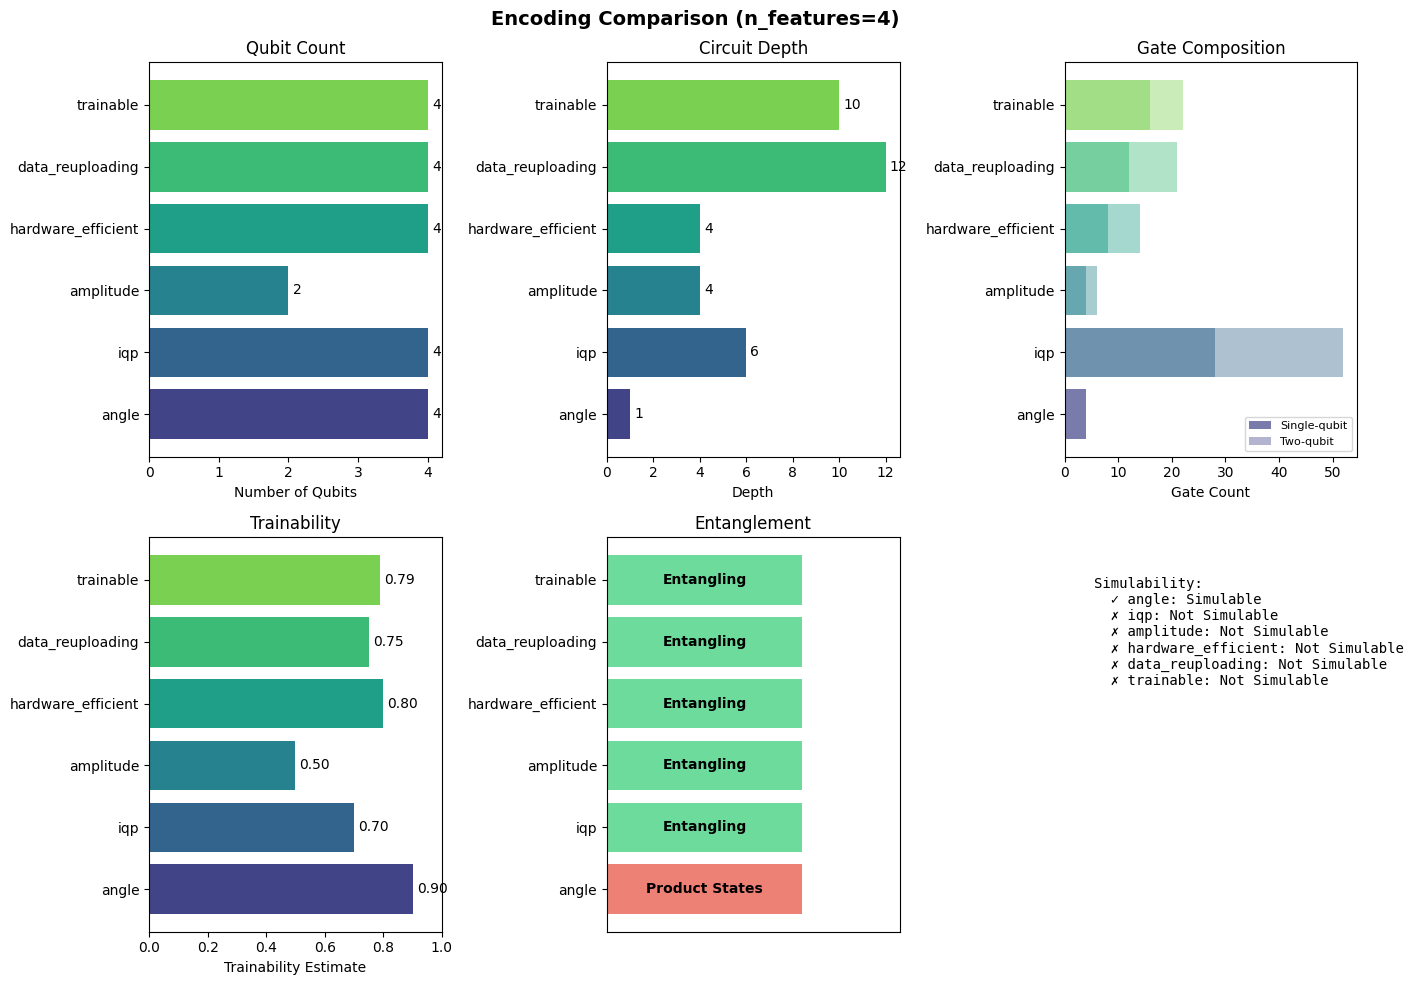

In [82]:
# Matplotlib figure (for papers and presentations)
try:
    import matplotlib
    fig = compare_encodings(
        ["angle", "iqp", "amplitude", "hardware_efficient", "data_reuploading", "trainable"],
        n_features=4,
        output="matplotlib",
        figsize=(14, 10),
    )
    # fig.savefig("encoding_comparison.pdf", dpi=300, bbox_inches="tight")
    print(f"Generated matplotlib figure: {type(fig).__name__}")
except Exception as e:
    print(f"Matplotlib comparison: {e}")

---
## 13. Guided Encoding Selection

Let the library recommend an encoding based on your problem characteristics.

In [83]:
from encoding_atlas.guide import recommend_encoding, Recommendation

# Scenario 1: Maximize accuracy on a simulator
rec = recommend_encoding(n_features=4, n_samples=500, task="classification", priority="accuracy")
print(f"Recommendation: {rec.encoding_name}")
print(f"  Explanation:  {rec.explanation}")
print(f"  Alternatives: {rec.alternatives}")
print(f"  Confidence:   {rec.confidence}")

Recommendation: iqp
  Explanation:  IQP encoding is expressive for small feature sets with sufficient data
  Alternatives: ['zz_feature_map', 'data_reuploading']
  Confidence:   0.75


In [84]:
# Scenario 2: Optimize for speed
rec_fast = recommend_encoding(n_features=4, task="classification", priority="speed")
print(f"Speed priority → {rec_fast.encoding_name}: {rec_fast.explanation}")

# Scenario 3: Running on real hardware
rec_hw = recommend_encoding(n_features=4, hardware="ibm", priority="noise_resilience")
print(f"IBM hardware → {rec_hw.encoding_name}: {rec_hw.explanation}")

# Use the recommendation directly
enc = get_encoding(rec.encoding_name, n_features=4)
print(f"\nInstantiated: {enc.__class__.__name__} (depth={enc.depth})")

Speed priority → angle: Angle encoding is fastest with O(1) depth
IBM hardware → hardware_efficient: Hardware-efficient encoding minimizes errors on real devices

Instantiated: IQPEncoding (depth=6)


---
## 14. Benchmarking Datasets & Metrics

In [85]:
from encoding_atlas.benchmark import list_datasets, get_dataset, compute_metrics

# Available datasets
print(f"Available datasets: {list_datasets()}")

# Load datasets
for ds_name in list_datasets():
    try:
        X, y = get_dataset(ds_name, n_samples=100, seed=42)
        print(f"  {ds_name:10s} → X{X.shape}, y{y.shape}, classes={np.unique(y)}")
    except ImportError as e:
        print(f"  {ds_name:10s} → skipped ({e})")

Available datasets: ['iris', 'moons', 'circles', 'linear', 'xor']
  iris       → X(100, 2), y(100,), classes=[0 1]
  moons      → X(100, 2), y(100,), classes=[0 1]
  circles    → X(100, 2), y(100,), classes=[0 1]
  linear     → X(100, 2), y(100,), classes=[0 1]
  xor        → X(100, 2), y(100,), classes=[0 1]


In [86]:
# Evaluation metrics
y_true = np.array([0, 0, 1, 1, 0, 1, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0, 1, 0])

metrics = compute_metrics(y_true, y_pred)
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-score:  {metrics['f1']:.4f}")

Accuracy:  0.7500
Precision: 0.7500
Recall:    0.7500
F1-score:  0.7500


---
## 15. End-to-End Workflow: Quantum Kernel Classification

A complete production pipeline: select encoding → build kernel matrix → classify with SVM.

In [87]:
from encoding_atlas import IQPEncoding
from encoding_atlas.analysis import simulate_encoding_statevector, compute_fidelity
from encoding_atlas.benchmark import get_dataset, compute_metrics

# Step 1: Load dataset
X, y = get_dataset("moons", n_samples=60, seed=42)
print(f"Dataset: X{X.shape}, y{y.shape}")

# Step 2: Scale features to [0, pi] for encoding
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

# Step 3: Pad to 4 features (IQP needs >= 2 features for entanglement)
X_4d = np.column_stack([X_scaled, X_scaled[:, 0]**2, X_scaled[:, 1]**2])
print(f"Padded features: {X_4d.shape}")

Dataset: X(60, 2), y(60,)
Padded features: (60, 4)


In [88]:
# Step 4: Choose encoding and build quantum kernel matrix
enc = IQPEncoding(n_features=4, reps=2, entanglement="full")

# Simulate statevectors for all samples
from encoding_atlas.analysis import simulate_encoding_statevectors_batch
statevectors = simulate_encoding_statevectors_batch(enc, X_4d)
print(f"Simulated {len(statevectors)} statevectors")

# Build kernel matrix K[i,j] = |<ψ(x_i)|ψ(x_j)>|^2
n = len(statevectors)
K = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        fid = compute_fidelity(statevectors[i], statevectors[j])
        K[i, j] = K[j, i] = fid ** 2

print(f"Kernel matrix: {K.shape}, diagonal mean = {np.diag(K).mean():.4f}")

Simulated 60 statevectors
Kernel matrix: (60, 60), diagonal mean = 1.0000


In [89]:
# Step 5: Train SVM with quantum kernel
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Split
train_idx, test_idx = train_test_split(range(n), test_size=0.3, random_state=42, stratify=y)
K_train = K[np.ix_(train_idx, train_idx)]
K_test = K[np.ix_(test_idx, train_idx)]
y_train, y_test = y[train_idx], y[test_idx]

# Fit
svm = SVC(kernel="precomputed")
svm.fit(K_train, y_train)
y_pred = svm.predict(K_test)

# Evaluate
results = compute_metrics(y_test, y_pred)
print(f"Quantum Kernel SVM Results:")
for metric, val in results.items():
    print(f"  {metric}: {val:.4f}")

Quantum Kernel SVM Results:
  accuracy: 0.6111
  precision: 0.6250
  recall: 0.5556
  f1: 0.5882


---
## 16. End-to-End Workflow: Encoding Selection Pipeline

Systematically evaluate multiple encodings to find the best one for your task.

In [90]:
from encoding_atlas import get_encoding
from encoding_atlas.analysis import (
    count_resources,
    check_simulability,
    compute_expressibility,
    compute_entanglement_capability,
    estimate_trainability,
)

# Define candidate encodings
candidates = {
    "angle":              {"n_features": 4, "rotation": "Y"},
    "iqp":                {"n_features": 4, "reps": 2, "entanglement": "full"},
    "zz_feature_map":     {"n_features": 4, "reps": 2},
    "hardware_efficient":  {"n_features": 4, "reps": 2},
    "data_reuploading":    {"n_features": 4, "n_layers": 3},
}

# Multi-criteria evaluation
results = []
for name, kwargs in candidates.items():
    enc = get_encoding(name, **kwargs)
    props = enc.properties

    expr = compute_expressibility(enc, n_samples=100, seed=42)
    expr_val = expr['expressibility'] if isinstance(expr, dict) else expr

    ent = compute_entanglement_capability(enc, n_samples=50, seed=42)
    ent_val = ent['entanglement_capability'] if isinstance(ent, dict) else ent

    train = estimate_trainability(enc, n_samples=30, seed=42)
    train_val = train['trainability_estimate'] if isinstance(train, dict) else train

    results.append({
        "name": name,
        "qubits": props.n_qubits,
        "depth": props.depth,
        "gates": props.gate_count,
        "entangling": props.is_entangling,
        "expressibility": expr_val,
        "entanglement": ent_val,
        "trainability": train_val,
    })

# Display results
print(f"{'Encoding':<22} {'Qubits':>6} {'Depth':>6} {'Gates':>6} {'Expr':>10} {'Entang':>10} {'Train':>10}")
print("-" * 78)
for r in results:
    print(f"{r['name']:<22} {r['qubits']:>6} {r['depth']:>6} {r['gates']:>6} "
          f"{r['expressibility']:>10.4f} {r['entanglement']:>10.4f} {r['trainability']:>10.4f}")

C:\Users\ashut\AppData\Local\Temp\ipykernel_26736\3364482934.py:28: UserWarning: n_samples=50 is low. For reliable entanglement capability estimates, use at least 100 samples.
  ent = compute_entanglement_capability(enc, n_samples=50, seed=42)
C:\Users\ashut\AppData\Local\Temp\ipykernel_26736\3364482934.py:31: UserWarning: n_samples=30 is below the recommended minimum of 50. Trainability estimates may be unreliable. Consider increasing n_samples for more accurate results.
  train = estimate_trainability(enc, n_samples=30, seed=42)


Encoding               Qubits  Depth  Gates       Expr     Entang      Train
------------------------------------------------------------------------------
angle                       4      1      4     0.9143     0.0000     0.0683
iqp                         4      6     52     0.9877     0.7723     0.0424
zz_feature_map              4     22     52     0.9789     0.7680     0.0555
hardware_efficient          4      4     14     0.9284     0.5281     0.0308
data_reuploading            4     12     21     0.9613     0.5317     0.0464


---
## 17. Advanced: Trainable Encoding Optimization Loop

Demonstrate how to use `TrainableEncoding` in a manual optimization loop.

In [91]:
from encoding_atlas import TrainableEncoding
from encoding_atlas.analysis import simulate_encoding_statevector, compute_fidelity

# Create a trainable encoding
enc = TrainableEncoding(
    n_features=2, n_layers=2,
    initialization="small_random", seed=42,
)

# Target: maximize fidelity between two data points' quantum states
# (toy example — in production you'd optimize a loss over a dataset)
x_a = np.array([0.5, 1.0])
x_b = np.array([2.5, 0.3])

# Get initial parameters
params = enc.get_trainable_parameters().copy()
print(f"Initial parameters: {params.round(4)}")

# Simple parameter perturbation loop
best_fidelity = 0.0
best_params = params.copy()
rng = np.random.default_rng(42)

for step in range(20):
    # Perturb parameters
    trial_params = params + 0.1 * rng.standard_normal(params.shape)
    enc.set_trainable_parameters(trial_params)

    # Evaluate
    sv_a = simulate_encoding_statevector(enc, x_a)
    sv_b = simulate_encoding_statevector(enc, x_b)
    fid = compute_fidelity(sv_a, sv_b)

    if fid > best_fidelity:
        best_fidelity = fid
        best_params = trial_params.copy()
        params = trial_params  # accept

    if step % 5 == 0:
        print(f"  Step {step:3d}: fidelity={fid:.4f} (best={best_fidelity:.4f})")

enc.set_trainable_parameters(best_params)
print(f"\nFinal best fidelity: {best_fidelity:.4f}")
print(f"Optimized parameters: {best_params.round(4)}")

Initial parameters: [[ 0.0548 -0.0122]
 [ 0.0717  0.0395]]
  Step   0: fidelity=0.1078 (best=0.1078)
  Step   5: fidelity=0.1207 (best=0.1384)
  Step  10: fidelity=0.1556 (best=0.1556)
  Step  15: fidelity=0.1946 (best=0.1946)

Final best fidelity: 0.2194
Optimized parameters: [[-0.1859  0.3447]
 [ 0.3529  0.136 ]]


---
## 18. Advanced: Equivariance Verification

Verify that the equivariant encodings satisfy their mathematical symmetry guarantees.

In [92]:
from encoding_atlas import SO2EquivariantFeatureMap, CyclicEquivariantFeatureMap, SwapEquivariantFeatureMap
from encoding_atlas.analysis import simulate_encoding_statevector

# SO(2) equivariance: rotating input = rotating output
so2 = SO2EquivariantFeatureMap(n_features=2, max_angular_momentum=2)

# Original 2D point
x = np.array([1.0, 0.0])

# Rotate by angle phi
phi = np.pi / 3
rotation_matrix = np.array([
    [np.cos(phi), -np.sin(phi)],
    [np.sin(phi),  np.cos(phi)],
])
x_rotated = rotation_matrix @ x

sv_original = simulate_encoding_statevector(so2, x)
sv_rotated = simulate_encoding_statevector(so2, x_rotated)

# The fidelity should reflect the equivariance relationship
fid = compute_fidelity(sv_original, sv_rotated)
print(f"SO(2) Equivariance test:")
print(f"  Original input:  {x}")
print(f"  Rotated input:   {x_rotated.round(4)}")
print(f"  State fidelity:  {fid:.6f}")

SO(2) Equivariance test:
  Original input:  [1. 0.]
  Rotated input:   [0.5   0.866]
  State fidelity:  0.103814


In [93]:
# Cyclic equivariance: cyclic shift of input = cyclic shift of qubits
cyclic = CyclicEquivariantFeatureMap(n_features=4, reps=2)

x = np.array([0.3, 0.7, 1.1, 0.5])
x_shifted = np.roll(x, 1)  # cyclic shift

sv1 = simulate_encoding_statevector(cyclic, x)
sv2 = simulate_encoding_statevector(cyclic, x_shifted)
fid = compute_fidelity(sv1, sv2)

print(f"\nCyclic Equivariance test:")
print(f"  Original: {x}")
print(f"  Shifted:  {x_shifted}")
print(f"  Fidelity: {fid:.6f}")


Cyclic Equivariance test:
  Original: [0.3 0.7 1.1 0.5]
  Shifted:  [0.5 0.3 0.7 1.1]
  Fidelity: 0.655025


In [94]:
# Swap equivariance: swapping feature pairs = swapping qubit pairs
swap_enc = SwapEquivariantFeatureMap(n_features=4, reps=2)

x = np.array([0.3, 0.7, 1.1, 0.5])
# Swap pairs: (x0, x1) <-> (x1, x0) and (x2, x3) <-> (x3, x2)
x_swapped = np.array([0.7, 0.3, 0.5, 1.1])

sv1 = simulate_encoding_statevector(swap_enc, x)
sv2 = simulate_encoding_statevector(swap_enc, x_swapped)
fid = compute_fidelity(sv1, sv2)

print(f"\nSwap Equivariance test:")
print(f"  Original: {x}")
print(f"  Swapped:  {x_swapped}")
print(f"  Fidelity: {fid:.6f}")


Swap Equivariance test:
  Original: [0.3 0.7 1.1 0.5]
  Swapped:  [0.7 0.3 0.5 1.1]
  Fidelity: 0.970639


---
## 19. Production Patterns: Serialization, Error Handling, Logging

Patterns you'll use when integrating `encoding-atlas` into production systems.

In [95]:
import pickle

# Pickle round-trip (for model checkpointing, job queues, etc.)
enc = IQPEncoding(n_features=4, reps=2)
_ = enc.properties  # force lazy computation before serialization

serialized = pickle.dumps(enc)
restored = pickle.loads(serialized)

print(f"Original:  {enc}")
print(f"Restored:  {restored}")
print(f"Equal:     {enc == restored}")
print(f"Hashable:  {hash(enc) == hash(restored)}")

# Verify the restored encoding still works
x = np.array([0.3, 1.2, 0.7, 2.1])
c1 = enc.get_circuit(x, backend="pennylane")
c2 = restored.get_circuit(x, backend="pennylane")
print(f"Circuits work after deserialization: True")

Original:  IQPEncoding(n_features=4, reps=2, entanglement='full')
Restored:  IQPEncoding(n_features=4, reps=2, entanglement='full')
Equal:     True
Hashable:  True
Circuits work after deserialization: True


In [96]:
# Equality and hashing (for sets, dicts, deduplication)
enc1 = IQPEncoding(n_features=4, reps=2)
enc2 = IQPEncoding(n_features=4, reps=2)  # same config
enc3 = IQPEncoding(n_features=4, reps=3)  # different config

print(f"enc1 == enc2: {enc1 == enc2}")
print(f"enc1 == enc3: {enc1 == enc3}")

# Use in sets to deduplicate
unique = {enc1, enc2, enc3}
print(f"Set of 3 → {len(unique)} unique encodings")

enc1 == enc2: True
enc1 == enc3: False
Set of 3 → 2 unique encodings


In [97]:
# Exception handling — the full hierarchy
from encoding_atlas.core.exceptions import (
    EncodingError,        # base — catch all encoding_atlas errors
    ValidationError,      # bad inputs
    BackendError,         # quantum backend failures
    RegistryError,        # unknown encoding names
    AnalysisError,        # analysis computation failures
    SimulationError,      # circuit simulation failures
    ConvergenceError,     # iterative analysis didn't converge
    NumericalInstabilityError,  # numerical issues
    InsufficientSamplesError,   # not enough samples
)

# Example: graceful error handling in a production pipeline
def safe_analyze(enc_name, n_features):
    """Analyze an encoding with comprehensive error handling."""
    try:
        enc = get_encoding(enc_name, n_features=n_features)
    except RegistryError as e:
        print(f"  Unknown encoding '{enc_name}': {e}")
        return None

    try:
        expr = compute_expressibility(enc, n_samples=50, seed=42)
        return expr
    except AnalysisError as e:
        print(f"  Analysis failed for {enc_name}: {e}")
        if hasattr(e, 'details'):
            print(f"    Details: {e.details}")
        return None

# Works fine
result = safe_analyze("iqp", 4)
print(f"IQP analysis: {type(result).__name__}")

# Unknown encoding — handled gracefully
result = safe_analyze("nonexistent", 4)

C:\Users\ashut\AppData\Local\Temp\ipykernel_26736\3518489364.py:24: UserWarning: n_samples=50 is low; results may be unreliable. Recommended minimum: 100.
  expr = compute_expressibility(enc, n_samples=50, seed=42)


IQP analysis: float
  Unknown encoding 'nonexistent': Unknown encoding 'nonexistent'. Available encodings: amplitude, angle, angle_ry, basis, covariant, covariant_feature_map, cyclic_equivariant, cyclic_equivariant_feature_map, data_reuploading, hamiltonian, hamiltonian_encoding, hardware_efficient, higher_order_angle, iqp, my_custom, pauli_feature_map, qaoa, qaoa_encoding, so2_equivariant, so2_equivariant_feature_map, swap_equivariant, swap_equivariant_feature_map, symmetry_inspired, symmetry_inspired_feature_map, trainable, trainable_encoding, zz_feature_map


In [98]:
# Input validation: the library validates inputs strictly
enc = AngleEncoding(n_features=4)

# Wrong number of features
try:
    enc.get_circuit(np.array([0.1, 0.2]), backend="pennylane")
except (ValidationError, ValueError) as e:
    print(f"Wrong features: {type(e).__name__}: {e}")

# NaN in input
try:
    enc.get_circuit(np.array([0.1, np.nan, 0.3, 0.4]), backend="pennylane")
except (ValidationError, ValueError) as e:
    print(f"NaN input:      {type(e).__name__}: {e}")

# Invalid constructor args
try:
    AngleEncoding(n_features=0)
except (ValidationError, ValueError) as e:
    print(f"n_features=0:   {type(e).__name__}: {e}")

# Odd features for SwapEquivariant (requires even)
try:
    SwapEquivariantFeatureMap(n_features=3)
except (ValidationError, ValueError) as e:
    print(f"Odd n_features: {type(e).__name__}: {e}")

Wrong features: ValueError: Expected 4 features, got 2
NaN input:      ValueError: Input contains NaN or infinite values
n_features=0:   ValueError: n_features must be a positive integer, got 0
Odd n_features: ValueError: n_features must be even, got 3


In [99]:
# Config serialization (JSON-compatible)
import json

enc = IQPEncoding(n_features=4, reps=2, entanglement="full")
config = enc.config  # read-only dict copy

config_json = json.dumps(config, indent=2)
print(f"Config as JSON:\n{config_json}")

# Properties as JSON
props_json = json.dumps(enc.properties.to_dict(), indent=2)
print(f"\nProperties as JSON:\n{props_json}")

Config as JSON:
{
  "reps": 2,
  "entanglement": "full"
}

Properties as JSON:
{
  "n_qubits": 4,
  "depth": 6,
  "gate_count": 52,
  "single_qubit_gates": 28,
  "two_qubit_gates": 24,
  "parameter_count": 20,
  "is_entangling": true,
  "simulability": "not_simulable",
  "expressibility": null,
  "entanglement_capability": null,
  "trainability_estimate": 0.7,
  "noise_resilience_estimate": null,
  "notes": "IQP encoding with full entanglement. Provably hard to simulate classically under standard assumptions."
}


---
## Summary: API Quick Reference

| What you want | How to do it |
|:---|:---|
| Create an encoding | `enc = AngleEncoding(n_features=4)` |
| Create by name (config-driven) | `enc = get_encoding("iqp", n_features=4, reps=2)` |
| List all encodings | `list_encodings()` |
| Register custom encoding | `@register_encoding("name")` |
| Generate a circuit | `enc.get_circuit(x, backend="pennylane")` |
| Batch circuits | `enc.get_circuits(X, backend="pennylane")` |
| Get properties | `enc.properties` (frozen, cached) |
| Count resources | `count_resources(enc)` |
| Compare resources | `compare_resources([enc1, enc2, ...])` |
| Check simulability | `check_simulability(enc)` |
| Measure expressibility | `compute_expressibility(enc, n_samples=500)` |
| Measure entanglement | `compute_entanglement_capability(enc, n_samples=500)` |
| Estimate trainability | `estimate_trainability(enc, n_samples=100)` |
| Detect barren plateaus | `detect_barren_plateau(grad_var, n_qubits, n_params)` |
| Simulate statevector | `simulate_encoding_statevector(enc, x)` |
| Compute fidelity | `compute_fidelity(state1, state2)` |
| Partial trace | `partial_trace_single_qubit(sv, n_qubits, keep_qubit)` |
| Entropies | `compute_von_neumann_entropy(rho)` |
| Parameter gradients | `compute_all_parameter_gradients(enc, x)` |
| Visualize comparison | `compare_encodings([...], n_features=4)` |
| Get recommendation | `recommend_encoding(n_features=4, task="classification")` |
| Load dataset | `get_dataset("moons", n_samples=200, seed=42)` |
| Compute metrics | `compute_metrics(y_true, y_pred)` |
| Check backend | `is_pennylane_available()` / `get_available_backends()` |
| Check capabilities | `is_resource_analyzable(enc)` / `isinstance(enc, ResourceAnalyzable)` |
| Query entanglement pairs | `enc.get_entanglement_pairs()` (if `EntanglementQueryable`) |
| Transform input | `enc.transform_input(x)` (if `DataTransformable`) |
| Trainable params | `enc.get_trainable_parameters()` / `enc.set_trainable_parameters(p)` |
| Serialize | `pickle.dumps(enc)` / `enc.config` / `enc.properties.to_dict()` |